In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import missingno as msno

irradiance = pd.read_csv("data/irradiance_anonymized.csv")
pv_data = pd.read_csv("data/pv_data.csv", sep=";")
weather = pd.read_csv("data/weather.csv")

In [4]:
irradiance["dt"] = pd.to_datetime(irradiance["dt"])
pv_data["timestamp"] = pd.to_datetime(pv_data["timestamp"])
weather["time"] = pd.to_datetime(weather["time"])

In [5]:
def missing_report(df):
    return pd.DataFrame({
        "Missing Values": df.isna().sum(),
        "Percentage": df.isna().mean() * 100
    }).sort_values("Percentage", ascending=False)

## Missing Values


### Strahlung

In [8]:
missing_report(irradiance)

,Missing Values,Percentage
dt,0,0.0
dt_iso,0,0.0
timezone,0,0.0
city_name,0,0.0
lat,0,0.0
lon,0,0.0
ghi_cloudy_sky,0,0.0
dni_cloudy_sky,0,0.0
dhi_cloudy_sky,0,0.0
ghi_clear_sky,0,0.0


### PV Data

In [11]:
missing_report(pv_data)

,Missing Values,Percentage
Wallbox (ID 0) Gesamtladeleistung,21308,18.708295
Wallbox (ID 0) Netzbezug,21308,18.708295
Wallbox (ID 0) Solarladeleistung,21308,18.708295
Wallbox Gesamtladeleistung,21308,18.708295
timestamp,0,0.000000
Ladezustand,0,0.000000
Batterie (Laden),0,0.000000
Batterie (Entladen),0,0.000000
Netzeinspeisung,0,0.000000
Netzbezug,0,0.000000


### Weather

In [10]:
missing_report(weather)

,Missing Values,Percentage
time,0,0.0
temperature_2m (°C),0,0.0
cloud_cover (%),0,0.0
wind_speed_10m (km/h),0,0.0
precipitation (mm),0,0.0
weather_code (wmo code),0,0.0
relative_humidity_2m (%),0,0.0
pressure_msl (hPa),0,0.0
cloud_cover_low (%),0,0.0
cloud_cover_mid (%),0,0.0


In [13]:
weather.describe()

,time,temperature_2m (°C),cloud_cover (%),wind_speed_10m (km/h),precipitation (mm),weather_code (wmo code),relative_humidity_2m (%),pressure_msl (hPa),cloud_cover_low (%),cloud_cover_mid (%),cloud_cover_high (%),wind_gusts_10m (km/h)
count,50520,50520.000000,50520.000000,50520.000000,50520.000000,50520.000000,50520.000000,50520.000000,50520.000000,50520.000000,50520.000000,50520.000000
mean,2022-11-18 11:30:00.000000256,10.823810,65.454691,11.431617,0.083882,11.593448,72.237292,1016.601669,29.909956,34.619220,41.202613,22.985903
min,2020-01-01 00:00:00,-18.400000,0.000000,0.000000,0.000000,0.000000,17.000000,980.500000,0.000000,0.000000,0.000000,1.100000
25%,2021-06-10 05:45:00,4.500000,26.000000,6.800000,0.000000,1.000000,61.000000,1011.100000,0.000000,0.000000,0.000000,13.300000
50%,2022-11-18 11:30:00,10.500000,89.000000,10.100000,0.000000,3.000000,75.000000,1016.900000,7.000000,15.000000,17.000000,20.500000
75%,2024-04-27 17:15:00,16.800000,100.000000,14.800000,0.000000,3.000000,85.000000,1022.500000,58.000000,74.000000,96.000000,29.900000
max,2025-10-05 23:00:00,36.900000,100.000000,51.400000,14.000000,75.000000,100.000000,1047.600000,100.000000,100.000000,100.000000,97.900000
std,NaN,8.062071,39.276774,6.449521,0.343982,20.924026,16.315206,9.153113,38.763580,39.211891,43.809615,12.402464


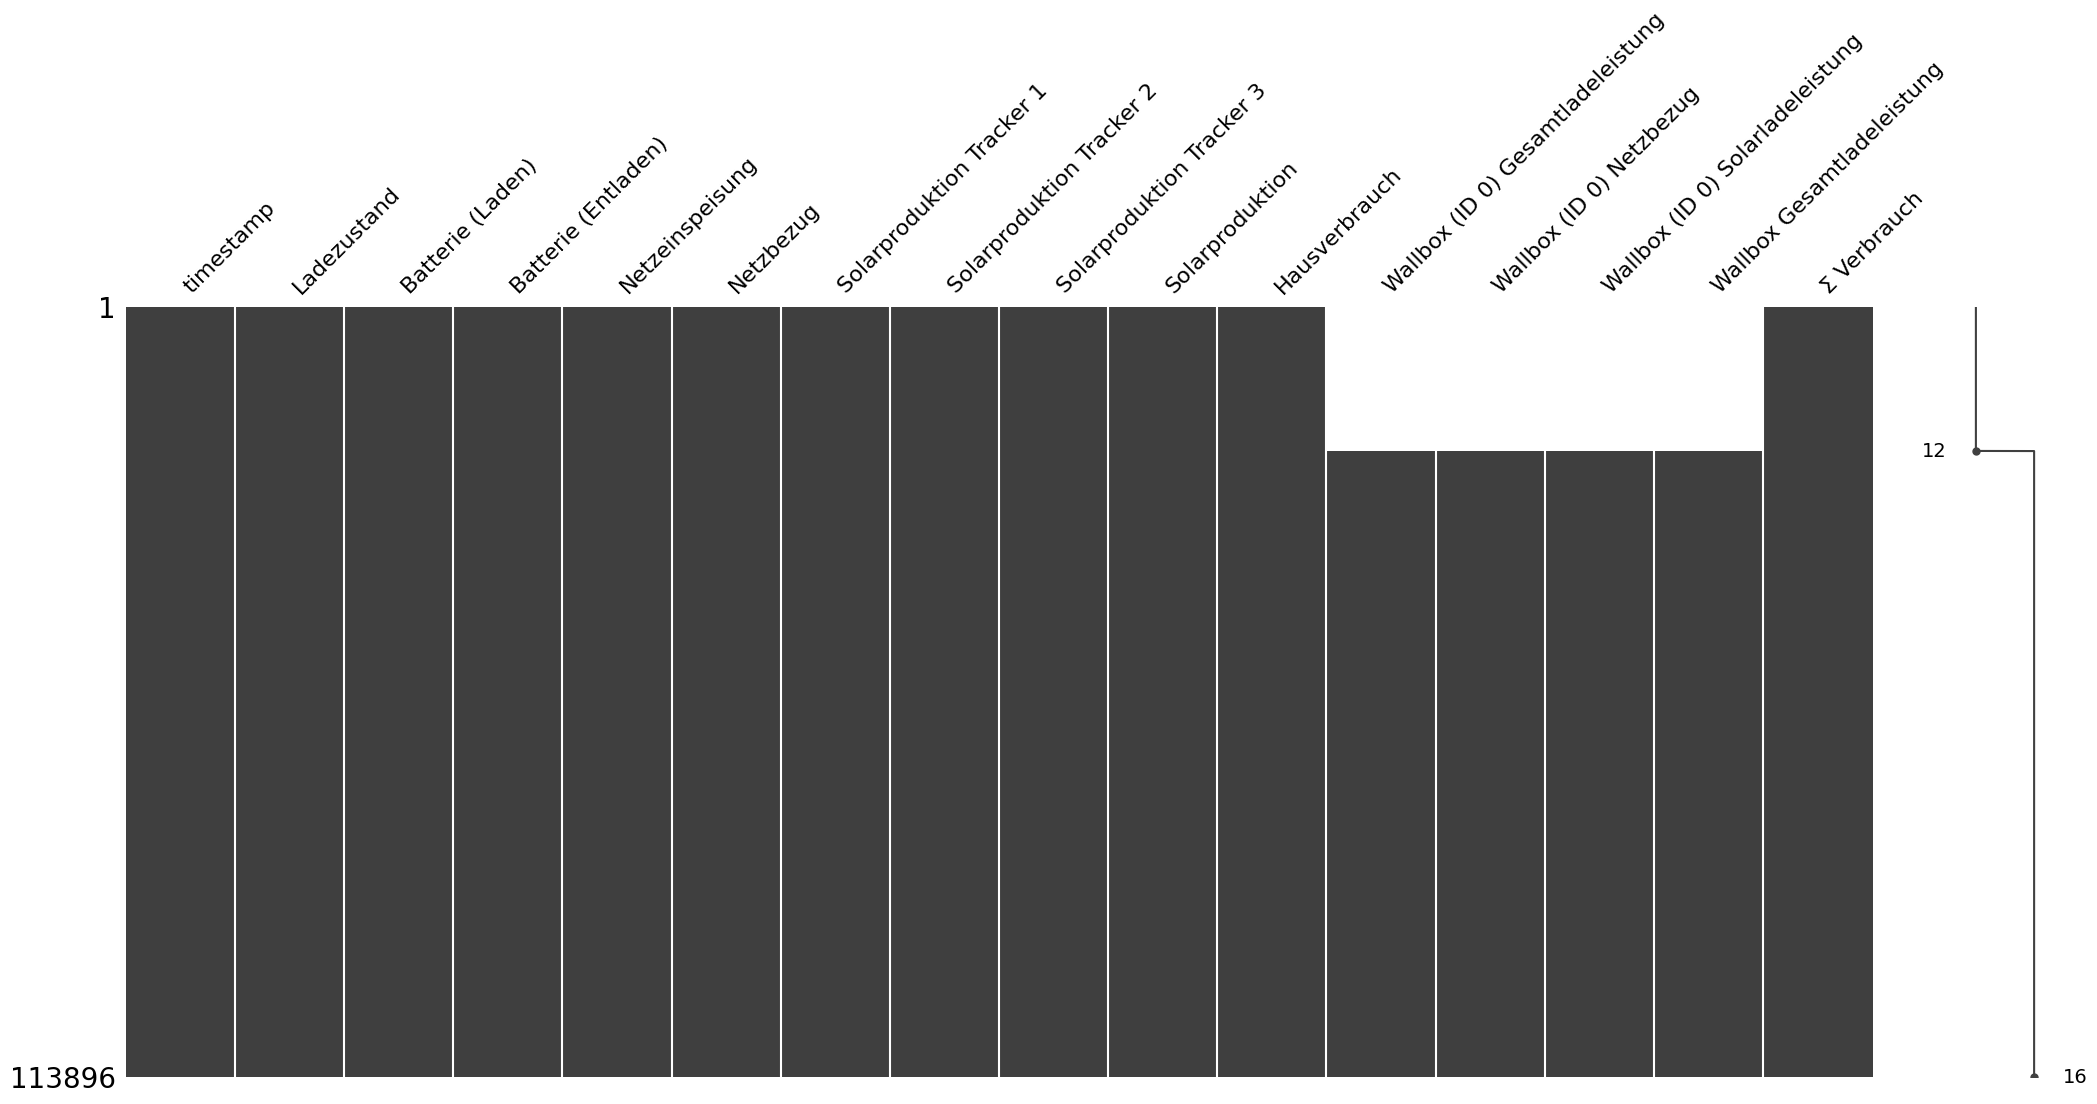

In [12]:
msno.matrix(pv_data)
plt.show()